# CNN for MNIST Digit Classification

Using device:cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 65.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.73MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.08MB/s]


Training samples : 60000
Test samples     : 10000
After split — Train: 50000, Validation: 10000

Model architecture:
MnistCNN(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
  )
  (gap): AdaptiveAvgPool2d(output_size=1)
  (fc): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total trainable parameters: 93,962

Starting Training
  Epoch 1 | Batch 200/782 | Loss: 1.2861 | Acc so far: 43.61%
  Epoch 1 | Batch 400/782 | Loss: 0.4909 | Acc so far: 62.11%
  Ep

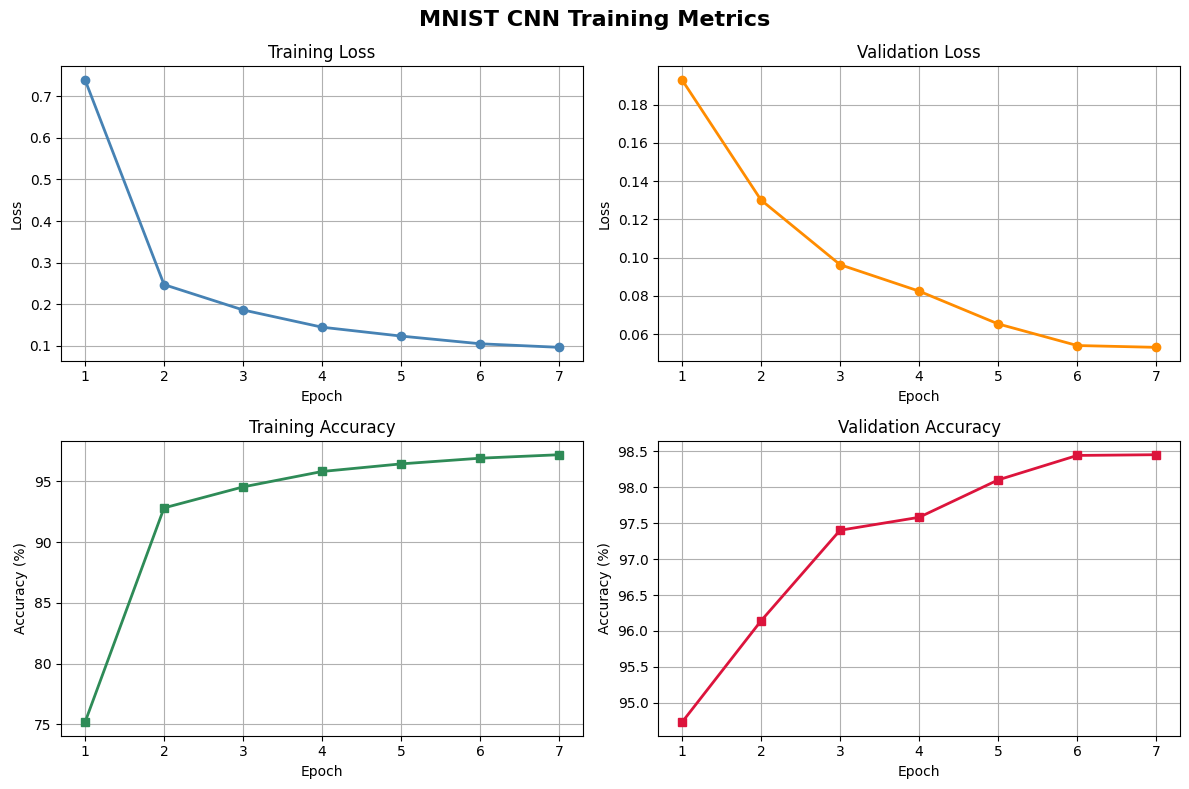


Plot saved as training_plots.png


In [2]:
'''conv1 -> Edge Detectors
   conv2 -> Stroke combinations
   conv3 -> Structural Patterns
   GAP -> Spatial Abstraction
   FC -> Decision Boundary'''

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.DataLoader
from torchvision import datasets,transforms
import matplotlib.pyplot as plt

EPOCHS = 7
BATCH_SIZE = 64
LR = 0.001

  #If GPU is available use it, otherwise use the CPU
  device  torch.device("cuda" if torch.cuda.is_available() else "cpu")
  print(f"Using device:{device}")

  transforms = transforms.Compose([
      transforms.ToTensor(),
      transforms.Normalize((0.1307),(0.3081))
  ])

train_dataset = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

print(f"Training samples : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")

train_size = 50000
val_size   = 10000

train_data, val_data = torch.utils.data.random_split(train_dataset, [train_size, val_size])

print(f"After split — Train: {len(train_data)}, Validation: {len(val_data)}")

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,batch_size=BATCH_SIZE, shuffle=False)

class MnistCNN(nn.Module):
  def __init__(self):
    super(MnistCNN,self).__init__()
    self.conv1 = nn.Sequential(
        nn.Conv2d(in_channels=1,out_channels=32,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2)
    )
    self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
    self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

    self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU()
        )

  self.gap = nn.AdaptiveAvgPool2d(output_size=1)
  self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features=128, out_features=10)
        )

  def forward(self, x):

        x = self.conv1(x)   # → (batch, 32, 14, 14)
        x = self.conv2(x)   # → (batch, 64,  7,  7)
        x = self.conv3(x)   # → (batch, 128, 7,  7)
        x = self.gap(x)     # → (batch, 128, 1,  1)

        # squeeze removes the dimensions of size 1
        # so (batch, 128, 1, 1) becomes (batch, 128)
        x = x.squeeze(-1).squeeze(-1)

        x = self.fc(x)      # → (batch, 10)

        # We return raw scores (logits). CrossEntropyLoss applies softmax internally.
        return x

model = MnistCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=LR)

print(f"\nModel architecture:\n{model}\n")

total_params = sum(p.numel()for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}\n")

def evaluate(loader):
    model.eval()
    total_loss     = 0.0
    total_correct  = 0
    total_samples  = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)           # forward pass
            loss    = criterion(outputs, labels)

            total_loss    += loss.item() * images.size(0)  # sum up batch loss
            preds          = outputs.argmax(dim=1)         # pick class with highest score
            total_correct += (preds == labels).sum().item()
            total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples * 100
    return avg_loss, accuracy

history = {
    "train_loss": [], "val_loss": [],
    "train_acc" : [], "val_acc" : []
}

print("Starting Training")

for epoch in range(1,EPOCHS+1):
  model.train()

  running_loss    = 0.0
  running_correct = 0
  running_samples = 0

  for batch_idx, (images, labels) in enumerate(train_loader):
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss    += loss.item() * images.size(0)
    preds            = outputs.argmax(dim=1)
    running_correct += (preds == labels).sum().item()
    running_samples += images.size(0)

    if (batch_idx + 1) % 200 == 0:
            so_far_acc = running_correct / running_samples * 100
            print(f"  Epoch {epoch} | Batch {batch_idx+1}/{len(train_loader)} "
                  f"| Loss: {loss.item():.4f} | Acc so far: {so_far_acc:.2f}%")


  train_loss = running_loss / running_samples
  train_acc  = running_correct / running_samples * 100

  val_loss, val_acc = evaluate(val_loader)

  history["train_loss"].append(train_loss)
  history["val_loss"].append(val_loss)
  history["train_acc"].append(train_acc)
  history["val_acc"].append(val_acc)

  print(f"\nEpoch {epoch}/{EPOCHS} Summary:")
  print(f"  Train Loss: {train_loss:.4f}  |  Train Acc: {train_acc:.2f}%")
  print(f"  Val   Loss: {val_loss:.4f}  |  Val   Acc: {val_acc:.2f}%")
  print("-" * 55)


test_loss, test_acc = evaluate(test_loader)
print(f"\nFinal Test Results:")
print(f"  Test Loss    : {test_loss:.4f}")
print(f"  Test Accuracy: {test_acc:.2f}%")

epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
fig.suptitle("MNIST CNN Training Metrics", fontsize=16, fontweight="bold")

# --- Training Loss ---
axes[0, 0].plot(epochs_range, history["train_loss"], marker="o", color="steelblue", linewidth=2)
axes[0, 0].set_title("Training Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].grid(True)

# --- Validation Loss ---
axes[0, 1].plot(epochs_range, history["val_loss"], marker="o", color="darkorange", linewidth=2)
axes[0, 1].set_title("Validation Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].grid(True)

# --- Training Accuracy ---
axes[1, 0].plot(epochs_range, history["train_acc"], marker="s", color="seagreen", linewidth=2)
axes[1, 0].set_title("Training Accuracy")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy (%)")
axes[1, 0].grid(True)

# --- Validation Accuracy ---
axes[1, 1].plot(epochs_range, history["val_acc"], marker="s", color="crimson", linewidth=2)
axes[1, 1].set_title("Validation Accuracy")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Accuracy (%)")
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig("training_plots.png", dpi=150)
plt.show()
print("\nPlot saved as training_plots.png")

Device: cpu


100%|██████████| 9.91M/9.91M [00:02<00:00, 4.54MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.95MB/s]


Train: 50000 | Val: 10000 | Test: 10000

Total trainable parameters: 567,434

Training ANN
Epoch 1/7 | Train Loss: 0.3041  Train Acc: 90.51%  |  Val Loss: 0.1513  Val Acc: 95.45%
Epoch 2/7 | Train Loss: 0.1453  Train Acc: 95.57%  |  Val Loss: 0.1249  Val Acc: 96.55%
Epoch 3/7 | Train Loss: 0.1148  Train Acc: 96.54%  |  Val Loss: 0.1029  Val Acc: 96.96%
Epoch 4/7 | Train Loss: 0.0977  Train Acc: 97.03%  |  Val Loss: 0.1002  Val Acc: 97.34%
Epoch 5/7 | Train Loss: 0.0854  Train Acc: 97.36%  |  Val Loss: 0.0815  Val Acc: 97.85%
Epoch 6/7 | Train Loss: 0.0793  Train Acc: 97.59%  |  Val Loss: 0.0790  Val Acc: 97.69%
Epoch 7/7 | Train Loss: 0.0700  Train Acc: 97.82%  |  Val Loss: 0.0787  Val Acc: 97.88%

Test Loss: 0.0683  |  Test Accuracy: 97.93%
Parameters: 567,434
METRICS FOR COMPARISON REPORT
  Model           : Fully Connected ANN
  Architecture    : 784 → 512 → 256 → 128 → 10
  Total Params    : 567,434
  Test Accuracy   : 97.93%
  Test Loss       : 0.0683
  Best Val Acc    : 97.88%
  

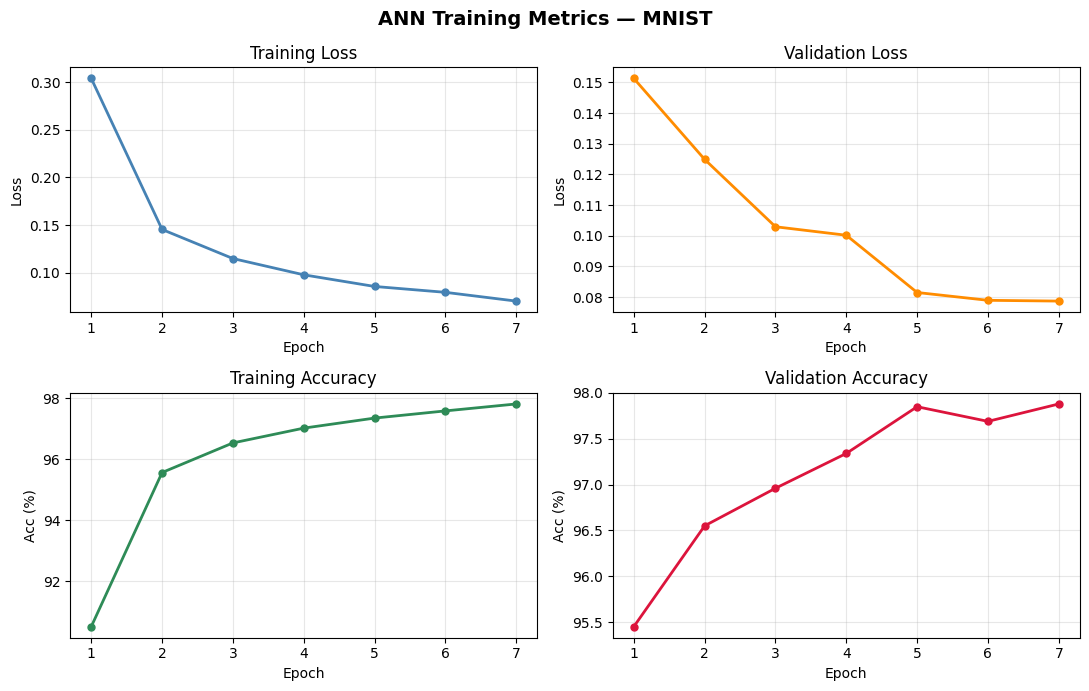

Plot saved as ann_training_plots.png


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

EPOCHS     = 7
BATCH_SIZE = 64
LR         = 0.001

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Unlike CNN, we then FLATTEN the image to a 1-D vector of 784 values.

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])


train_dataset = datasets.MNIST("./data", train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST("./data", train=False, download=True, transform=transform)

train_data, val_data = random_split(train_dataset, [50000, 10000])

train_loader = DataLoader(train_data,   batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_data,     batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_dataset)}")


class MnistANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),           # 1×28×28 → 784

            nn.Linear(784, 512),    # Layer 1: 784 inputs × 512 neurons  + 512 biases = 401,920 params
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),    # Layer 2: 512×256 + 256 = 131,328 params
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),    # Layer 3: 256×128 + 128 = 32,896 params
            nn.ReLU(),

            nn.Linear(128, 10),     # Output:  128×10  + 10  = 1,290 params

        )

    def forward(self, x):
        return self.net(x)


model     = MnistANN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")



def evaluate(loader):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            out   = model(images)
            loss  = criterion(out, labels)
            total_loss += loss.item() * images.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            n          += images.size(0)
    return total_loss / n, correct / n * 100



history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

print("\n" + "="*55)
print("Training ANN")
print("="*55)

for epoch in range(1, EPOCHS + 1):
    model.train()
    run_loss, run_correct, run_n = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(images)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()

        run_loss    += loss.item() * images.size(0)
        run_correct += (out.argmax(1) == labels).sum().item()
        run_n       += images.size(0)

    t_loss = run_loss / run_n
    t_acc  = run_correct / run_n * 100
    v_loss, v_acc = evaluate(val_loader)

    history["train_loss"].append(t_loss)
    history["val_loss"].append(v_loss)
    history["train_acc"].append(t_acc)
    history["val_acc"].append(v_acc)

    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {t_loss:.4f}  Train Acc: {t_acc:.2f}%"
          f"  |  Val Loss: {v_loss:.4f}  Val Acc: {v_acc:.2f}%")


test_loss, test_acc = evaluate(test_loader)
print(f"\nTest Loss: {test_loss:.4f}  |  Test Accuracy: {test_acc:.2f}%")
print(f"Parameters: {total_params:,}")




print("METRICS FOR COMPARISON REPORT")

print(f"  Model           : Fully Connected ANN")
print(f"  Architecture    : 784 → 512 → 256 → 128 → 10")
print(f"  Total Params    : {total_params:,}")
print(f"  Test Accuracy   : {test_acc:.2f}%")
print(f"  Test Loss       : {test_loss:.4f}")
print(f"  Best Val Acc    : {max(history['val_acc']):.2f}%")
print(f"  Best Val Loss   : {min(history['val_loss']):.4f}")
print(f"  Final Train Acc : {history['train_acc'][-1]:.2f}%")
print(f"  Final Train Loss: {history['train_loss'][-1]:.4f}")
print("="*55)


epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
fig.suptitle("ANN Training Metrics — MNIST", fontsize=14, fontweight="bold")

plots = [
    (axes[0,0], history["train_loss"], "Training Loss",      "Loss",       "steelblue"),
    (axes[0,1], history["val_loss"],   "Validation Loss",    "Loss",       "darkorange"),
    (axes[1,0], history["train_acc"],  "Training Accuracy",  "Acc (%)",    "seagreen"),
    (axes[1,1], history["val_acc"],    "Validation Accuracy","Acc (%)",    "crimson"),
]
for ax, data, title, ylabel, color in plots:
    ax.plot(epochs_range, data, 'o-', color=color, linewidth=2, markersize=5)
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
    ax.set_xticks(epochs_range); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ann_training_plots.png", dpi=150)
plt.show()
print("Plot saved as ann_training_plots.png")